# **Arithmetic and Bitwise Operations**

## Objectives:
1. Arithmetic Operations
2. Bitwise Operations

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
# Our Setup, Import Libaries, Create our Imshow Function 
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

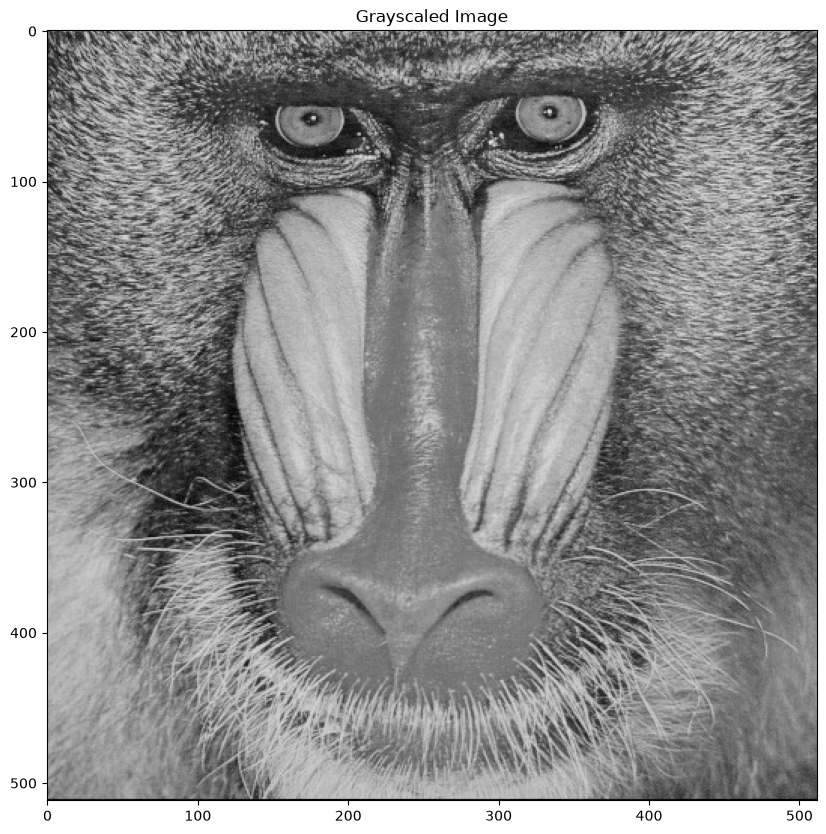

[[147  58  43 ... 114 150 178]
 [110 105  47 ... 132 148 127]
 [ 82 112  45 ... 101  86  80]
 ...
 [142 143 150 ...  84  92  77]
 [155 144 128 ...  77  77  70]
 [ 13   7  14 ...   6  10   1]]


In [2]:
# Adding comma zero in cv2.imread loads our image in as a grayscaled image
image = cv2.imread('assets/images/baboon.jpg', 0)
imshow("Grayscaled Image",image)
print(image)

# Create a matrix of ones, then multiply it by a scaler of 100 
# This gives a matrix with same dimesions of our image with all values being 100
M = np.ones(image.shape, dtype = "uint8") * 100 

In [3]:
print(M)

[[100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]
 ...
 [100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]]


## **Increasing Brightness**

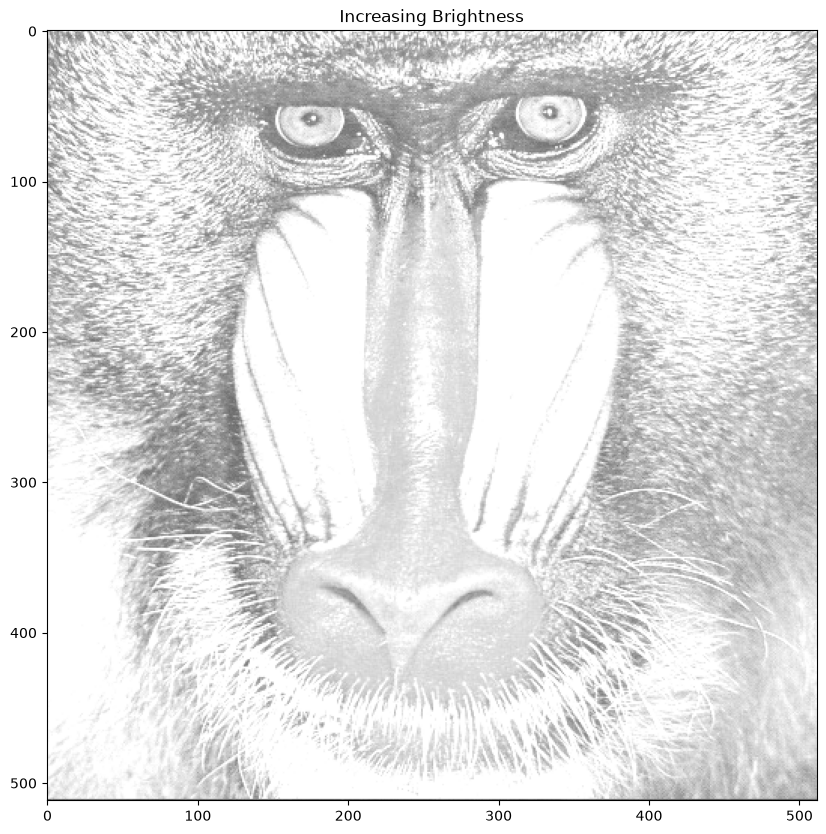

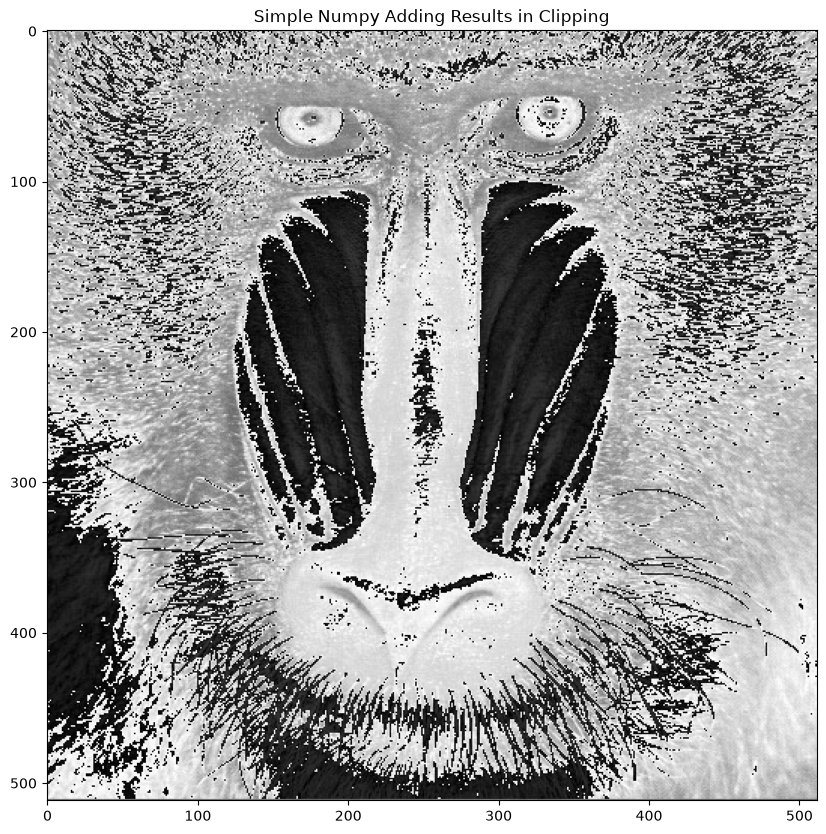

In [4]:
# We use this to add this matrix M, to our image
# Notice the increase in brightness
added = cv2.add(image, M)
imshow("Increasing Brightness", added)

# Now if we just added it, look what happens
added2 = image + M 
imshow("Simple Numpy Adding Results in Clipping", added2)

## **Decreasing Brightness**

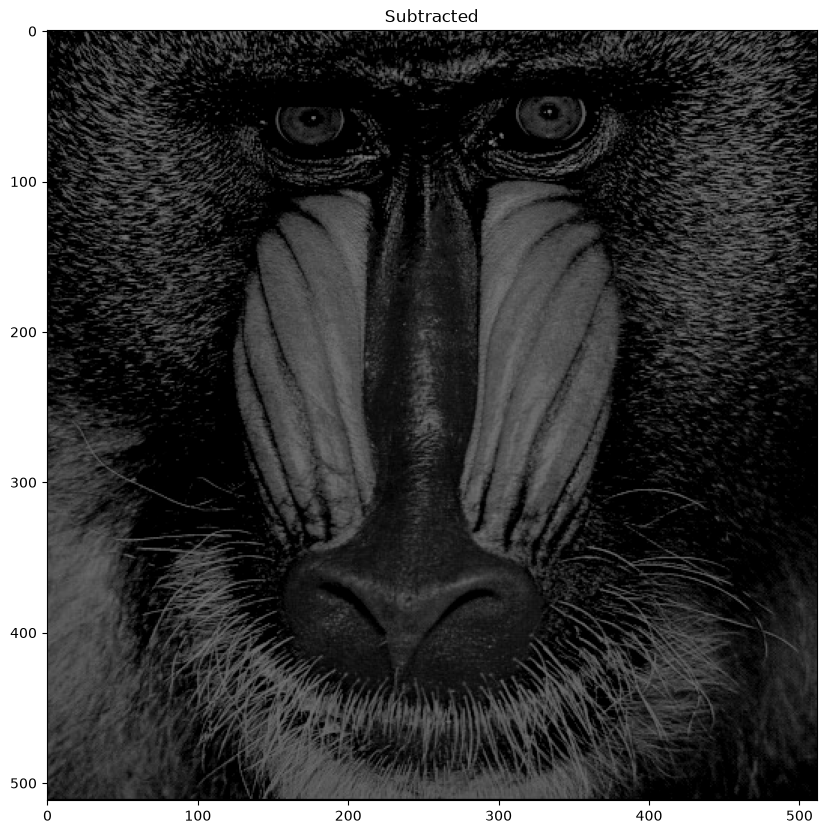

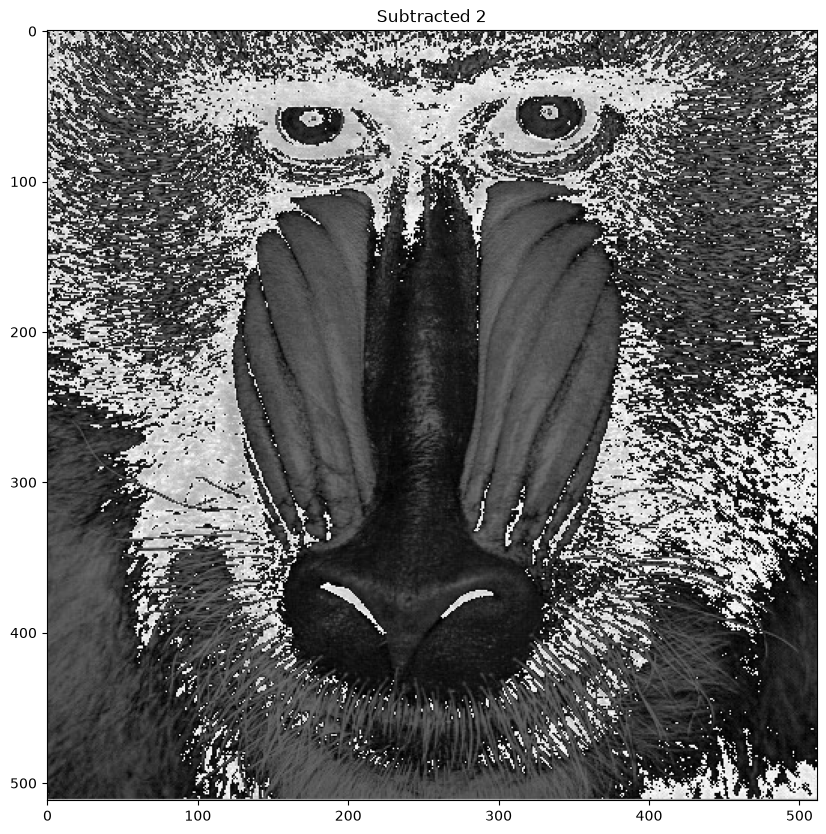

In [5]:
# Likewise we can also subtract
# Notice the decrease in brightness
subtracted = cv2.subtract(image, M)
imshow("Subtracted", subtracted)

subtracted = image - M 
imshow("Subtracted 2", subtracted)


## **Bitwise Operations and Masking**

For testing, let's create some simple images

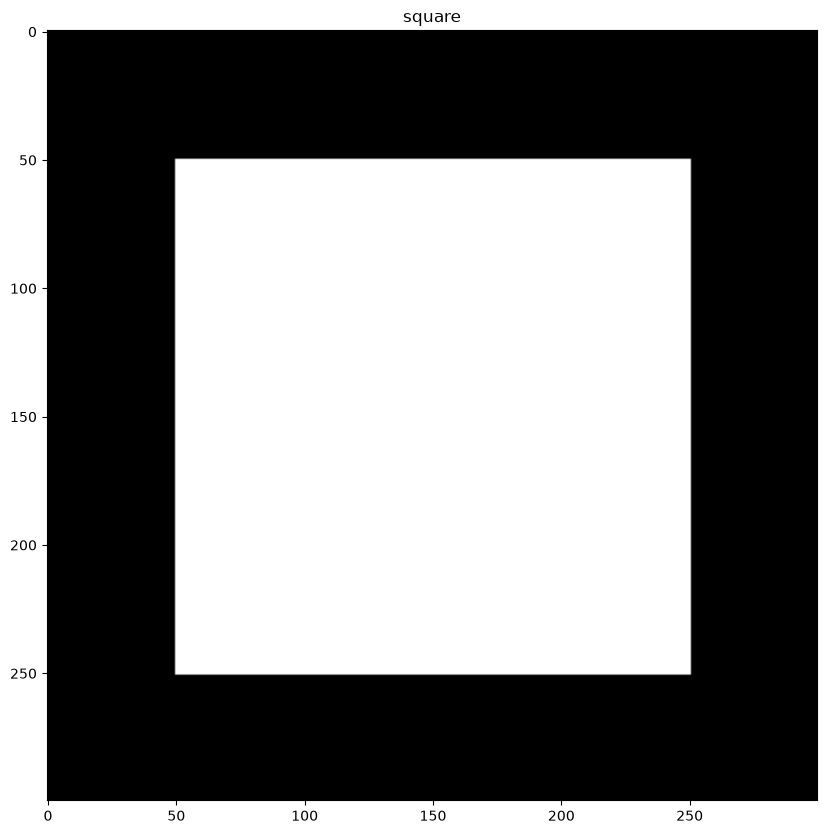

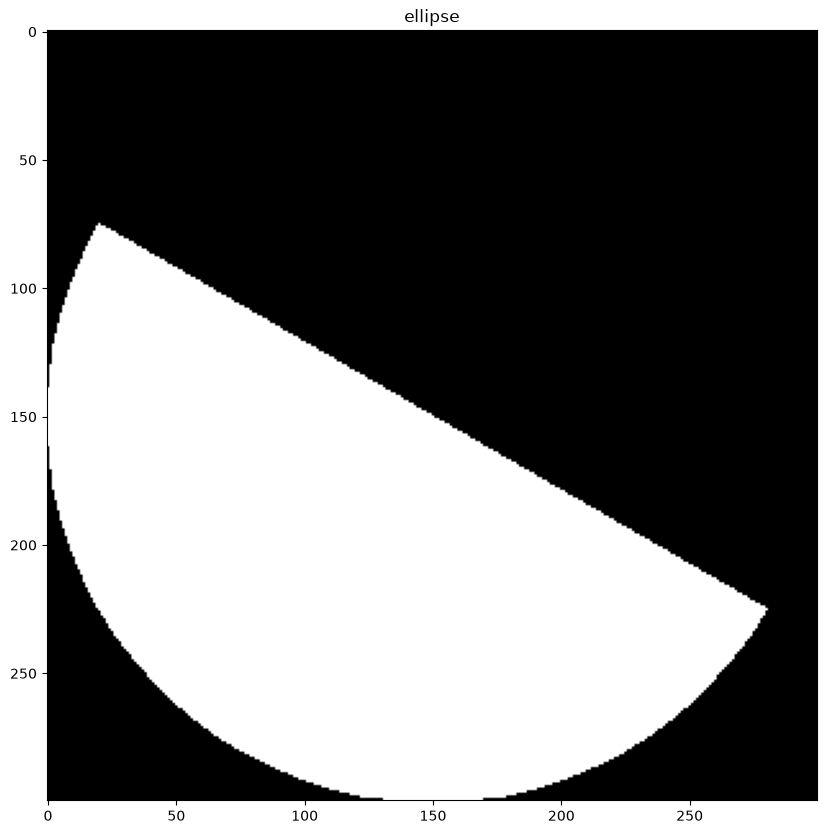

In [6]:
# Making a square
square = np.zeros((300, 300), np.uint8)
cv2.rectangle(square, (50, 50), (250, 250), 255, -2)
imshow("square", square)

# Making a ellipse
ellipse = np.zeros((300, 300), np.uint8)
cv2.ellipse(ellipse, (150, 150), (150, 150), 30, 0, 180, 255, -1)
imshow("ellipse", ellipse)

## **Experimenting with some bitwise operations such as AND, OR, XOR and NOT**

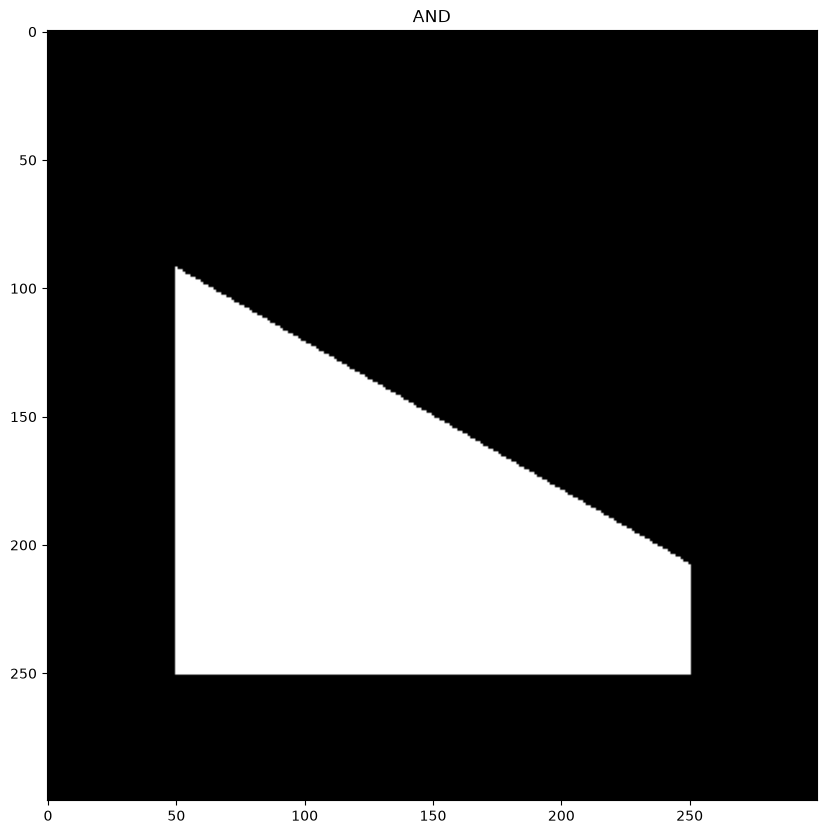

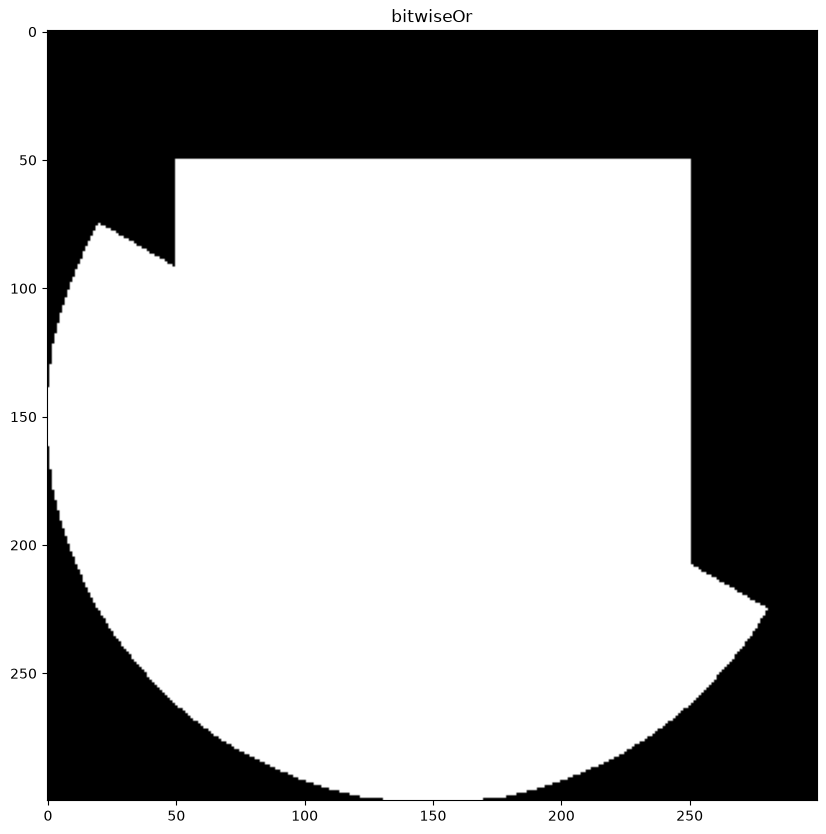

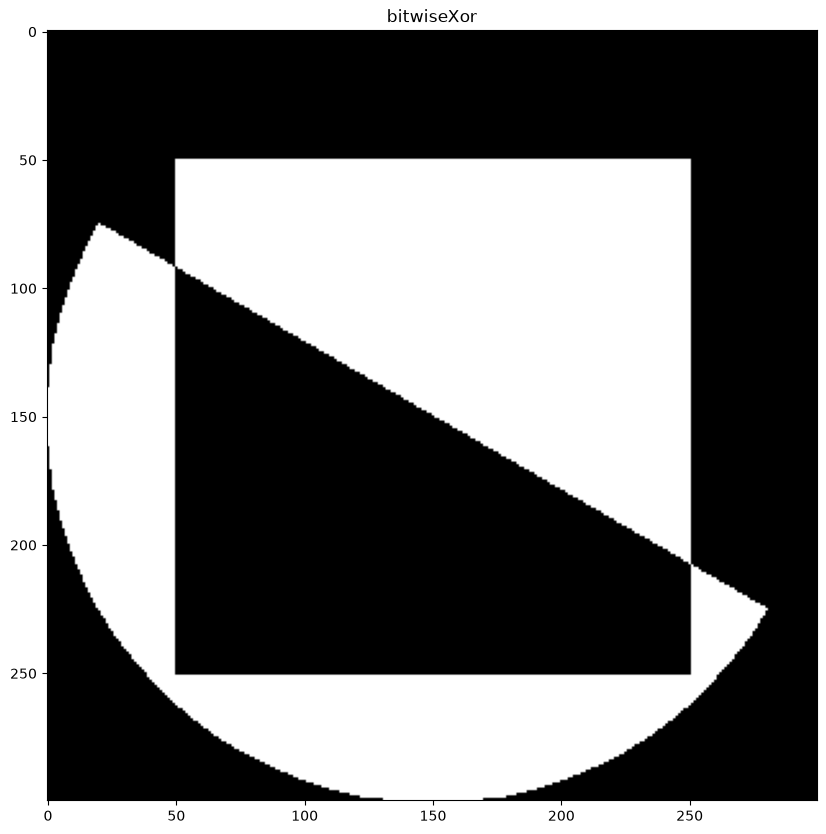

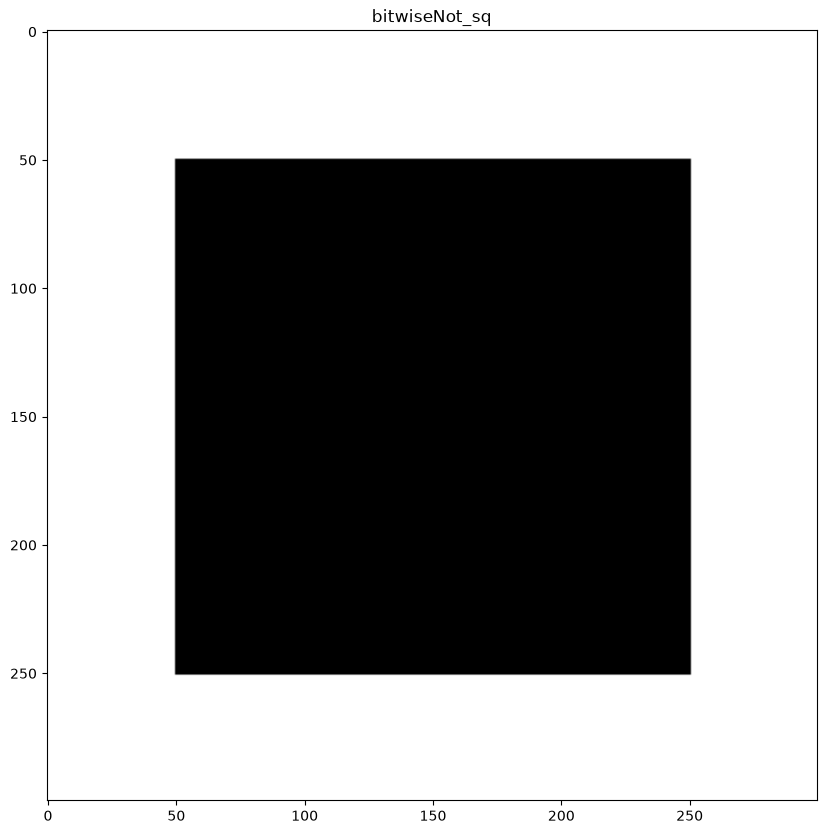

In [7]:
# Shows only where they intersect
And = cv2.bitwise_and(square, ellipse)
imshow("AND", And)

# Shows where either square or ellipse is 
bitwiseOr = cv2.bitwise_or(square, ellipse)
imshow("bitwiseOr", bitwiseOr)

# Shows where either exist by itself
bitwiseXor = cv2.bitwise_xor(square, ellipse)
imshow("bitwiseXor", bitwiseXor)

# Shows everything that isn't part of the square
bitwiseNot_sq = cv2.bitwise_not(square)
imshow("bitwiseNot_sq", bitwiseNot_sq)

# Notice the last operation inverts the image totally

### One or two things to try next

- Use `cv2.bitwise_and` with a real image mask instead of a synthetic square/ellipse: load `images/opencv-logo-white.png` as grayscale, threshold it, and use it to mask `images/baboon.jpg` — a preview of how logo-watermarking works.
- `cv2.add` clips at 255; plain NumPy `+` wraps around instead. Prove it on a single pixel: `print(np.uint8(250) + np.uint8(10))` vs `cv2.add(np.uint8([250]), np.uint8([10]))`.